# A basic global magnetization model

This notebook goes through the steps of making a basic model for the long-wavelength magnetic field of Earth. 

The magnetization is taken from the susceptibility model constructed by Hemant and Maus (2005). 

In [1]:
# add relative path the remit folder
import sys
sys.path.append('../')

# import basic dependencies
import matplotlib.pyplot as plt
import numpy as np
import pygmt

%load_ext autoreload
%autoreload 2

The curiesphere code contains a convenience function to load predefined susceptibility models. 

The Hemant and Maus (2005) is one of these. The model is defined as a global map, with each pixel representing the vertically integrated susceptibility (VIS) at that location, ie the sum of all susceptibilies at different depths between the surface and the base of the crust.

The model is loaded into an object with the type 'GlobalVIS', which is a class defined in the code to describe vertically integrated susceptibility maps.

In [19]:
from remit.data.models import load_vis_model

vis = load_vis_model()

print(vis)

## Plot the susceptibility model

The VIS here is just a 2D array in longitude and latitude. We can plot it as follows:

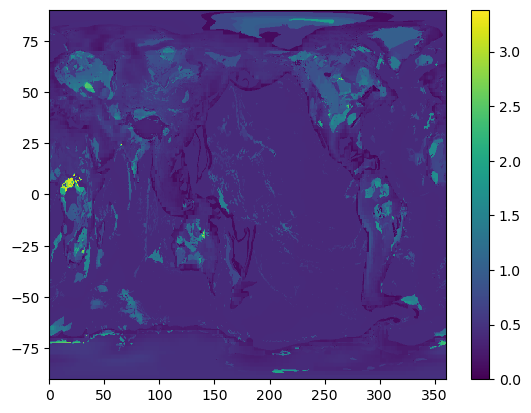

In [6]:
plt.pcolormesh(vis.lon, vis.lat, vis.vis)
plt.colorbar()

## Generate a magnetization model

A vis class object contains an inbuilt method to convert the susceptiility to magnetization. By default the VIS is multiplied by the components of the current IGRF to get Bx, By and Bz

(<Figure size 1500x400 with 6 Axes>, <Axes: title={'center': 'Mphi'}>)

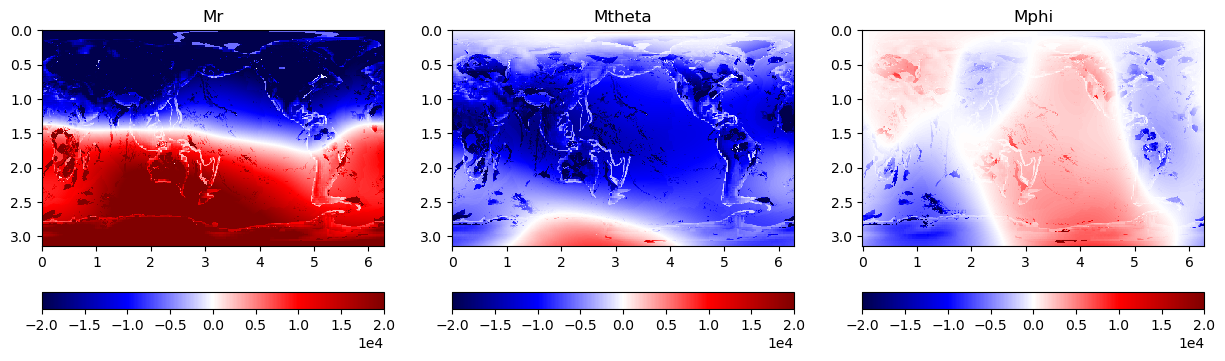

In [20]:
simple_vim = vis.vim()

simple_vim.plot()

## Model the magnetic field observed by satellites

Perform the forward Vector Spherical Harmonic transform.

We specify a maximum harmonic degree, in this case 140 is chosen since we want to compare our results to satellite data

In [22]:
lmax = 140
vsh, coeffs = simple_vim.transform(lmax=lmax)

The forward transform outputs both the vector spherical harmonic components and the spherical harmonic coefficients of the field. The spherical harmonics are returned as a pyshtools class

The function 'coeffs2map' function is a convenience function that takes the coefficients and generates a xarray grid of one of the three components of the field (by default the radial component is returned)

We specify the altitude to be 300 km to 

In [23]:
from remit.utils.grid import coeffs2map
model_rad = coeffs2map(coeffs, altitude=300000, lmax=lmax, lmin=16)


We can plot the radial map easily as follows

(<Figure size 640x352 with 1 Axes>,
 <Axes: xlabel='Longitude', ylabel='Latitude'>)

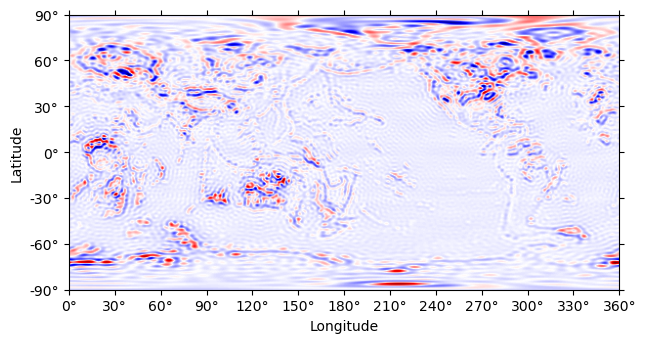

In [26]:
model_rad.plot(cmap='seismic')

To visualize the model output at a different altitude, simply change the altitude specified in coeffs2map

(<Figure size 640x352 with 1 Axes>,
 <Axes: xlabel='Longitude', ylabel='Latitude'>)

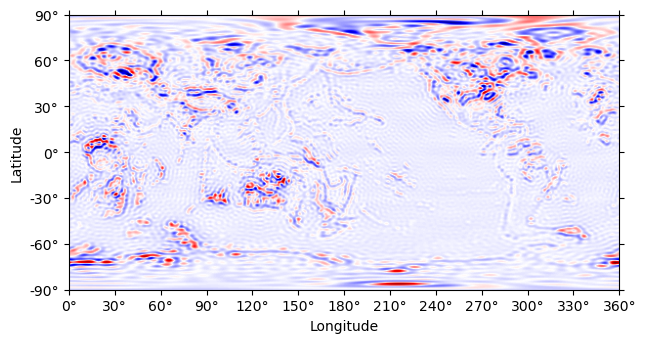

In [27]:
model_rad = coeffs2map(coeffs, altitude=0, lmax=lmax, lmin=16)
model_rad.plot(cmap='seismic')